### Importing all the important stuff for the lesson.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('drawndata1.csv')
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


In [4]:
x = df[['x', 'y']].values
y = df['z'] == 'a'

# x, y

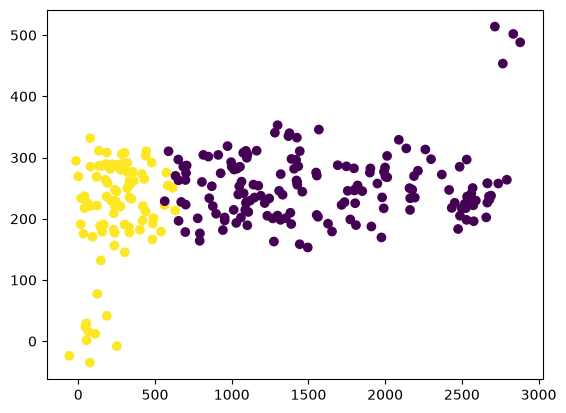

In [5]:
plt.scatter(x[:, 0], x[:, 1], c=y)

c:\Users\beast\OneDrive - ReachOut\Desktop\Scikit Learn\Day 1\slday1\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


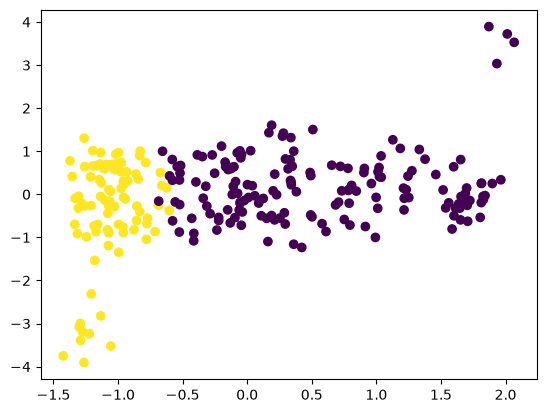

In [6]:
x_scaler = StandardScaler().fit_transform(x)
x_qt = QuantileTransformer().fit_transform(x)

plt.scatter(x_scaler[:, 0], x_scaler[:, 1], c=y);

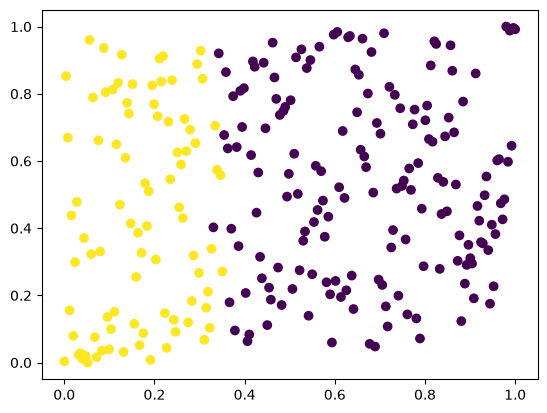

In [7]:
plt.scatter(x_qt[:, 0], x_qt[:, 1], c=y);

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

def plot_output(scaler):
    pipe = Pipeline([
        ('scale', scaler),
        ('model', KNeighborsClassifier())
    ])

    pred = pipe.fit(x, y).predict(x)

    plt.figure(figsize=(9,3))
    plt.subplot(131)
    plt.scatter(x[:, 0], x[:, 1], c=y)
    plt.title('Original Data')
    plt.subplot(132)
    x_tfm = scaler.transform(x)
    plt.scatter(x_tfm[:,0], x_tfm[:, 1], c=y)
    plt.title('Transformed Data')
    plt.subplot(133)
    x_new = np.concatenate([
        np.random.uniform(0, x[:, 0].max(), (5000, 1)),
        np.random.uniform(0, x[:, 1].max(), (5000, 1))
    ], axis=1)
    y_proba = pipe.predict_proba(x_new)
    plt.scatter(x_new[:, 0], x_new[:, 1], c=y_proba[:, 1], alpha=0.7)
    plt.title('Predicted Data')

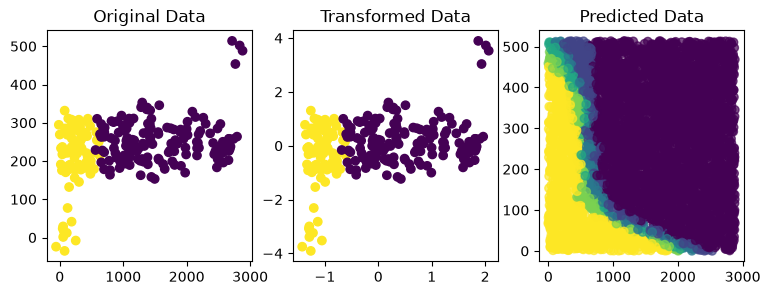

In [9]:
plot_output(scaler=StandardScaler())

c:\Users\beast\OneDrive - ReachOut\Desktop\Scikit Learn\Day 1\slday1\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (252). n_quantiles is set to n_samples.
  warnings.warn(


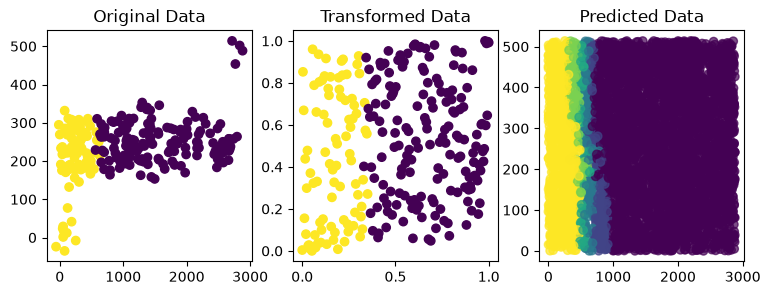

In [10]:
plot_output(scaler=QuantileTransformer())

## Dataset 2

In [11]:
df = pd.read_csv('drawndata2.csv')
df.head()

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a


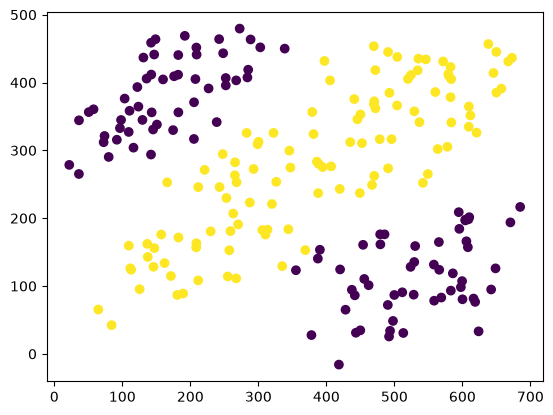

In [12]:
x = df[['x', 'y']].values
y = df['z'] == 'a'
plt.scatter(x[:,0], x[:, 1], c=y)

c:\Users\beast\OneDrive - ReachOut\Desktop\Scikit Learn\Day 1\slday1\Lib\site-packages\sklearn\preprocessing\_data.py:2905: UserWarning: n_quantiles (1000) is greater than the total number of samples (217). n_quantiles is set to n_samples.
  warnings.warn(


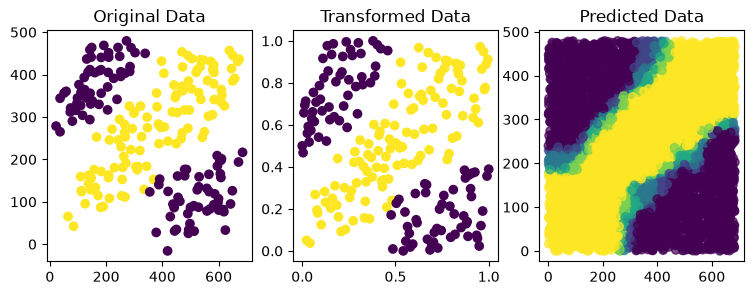

In [13]:
plot_output(scaler=QuantileTransformer(n_quantiles=1000))

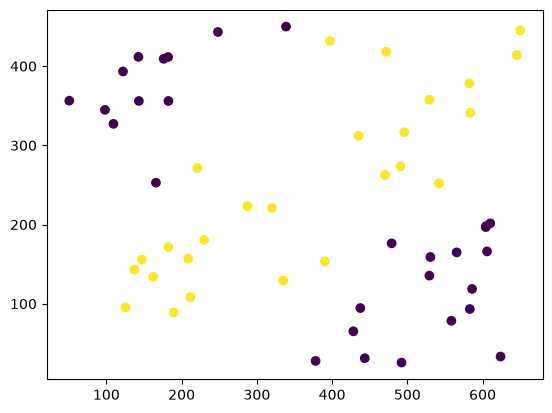

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y)

pipe = Pipeline([
    ('scale', PolynomialFeatures()),
    ('model', LogisticRegression())
])

#This is will be making an obvisously very wrong prediction.
pred = pipe.fit(x_train, y_train).predict(x_test)
plt.scatter(x_test[:, 0], x_test[:, 1], c=pred)

In [30]:
array = np.array(['low', 'low', 'high', 'medium']).reshape(-1,1)
array

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [37]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(array)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [38]:
enc.transform([['zero']])

array([[0., 0., 0.]])